## Submited by Alice Mataruse

### TOPIC: Predictive Analysis of Sales Channels and Profitability in Nike’s Retail Dataset Using Machine Learning

### BAN 668, Final Project Report

In [1]:
# import libraries 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.impute import SimpleImputer

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# load the 'Nike_Sales_Uncleaned.csv'
df=pd.read_csv('Nike_Sales_Uncleaned.csv')

## Data checking 

In [4]:
# Check first five rows 
df.head(100)

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,M,NaN,NaN,0.47,0.0,2024-03-09,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,NaN,0.0,2024-07-09,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,M,4.0,NaN,NaN,0.0,NaN,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,L,NaN,9673.57,NaN,0.0,04-10-2024,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,XL,NaN,NaN,NaN,0.0,2024/09/12,Retail,Delhi,187.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2095,Men,Lifestyle,Waffle One,M,NaN,NaN,NaN,0.0,16-10-2024,Online,Delhi,880.57
96,2096,Men,Running,Pegasus Turbo,XL,2.0,NaN,NaN,0.0,24-12-2024,Online,Kolkata,288.66
97,2097,Women,Training,ZoomX Invincible,XL,NaN,7978.89,NaN,0.0,NaN,Online,Bangalore,769.05
98,2098,Men,Training,ZoomX Invincible,L,NaN,5690.69,0.69,0.0,2024-01-24,Online,hyderbad,98.30


In [5]:
# Check basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Gender_Category   2500 non-null   object 
 2   Product_Line      2500 non-null   object 
 3   Product_Name      2500 non-null   object 
 4   Size              1990 non-null   object 
 5   Units_Sold        1265 non-null   float64
 6   MRP               1246 non-null   float64
 7   Discount_Applied  832 non-null    float64
 8   Revenue           2500 non-null   float64
 9   Order_Date        1884 non-null   object 
 10  Sales_Channel     2500 non-null   object 
 11  Region            2500 non-null   object 
 12  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage: 254.0+ KB


In [6]:
#Check for Missing Values
df.isnull().sum()

Order_ID               0
Gender_Category        0
Product_Line           0
Product_Name           0
Size                 510
Units_Sold          1235
MRP                 1254
Discount_Applied    1668
Revenue                0
Order_Date           616
Sales_Channel          0
Region                 0
Profit                 0
dtype: int64

In [7]:
# check the number of unique values 
cat_cols=df.select_dtypes('object')
for i in cat_cols:
    print(df[i].value_counts())
    print ('*'*20)

Gender_Category
Kids     841
Men      840
Women    819
Name: count, dtype: int64
********************
Product_Line
Training      546
Basketball    507
Lifestyle     501
Running       474
Soccer        472
Name: count, dtype: int64
********************
Product_Name
SuperRep Go           148
LeBron 20             144
Flex Trainer          141
ZoomX Invincible      140
Waffle One            137
React Infinity        134
Air Jordan            133
Phantom GT            130
Blazer Mid            127
Free RN               124
Air Force 1           121
Premier III           121
Metcon 7              117
Dunk Low              116
Kyrie Flytrap         116
Zoom Freak            114
Tiempo Legend         112
Mercurial Superfly    109
Pegasus Turbo         109
Air Zoom              107
Name: count, dtype: int64
********************
Size
L     513
XL    512
M     478
7      86
11     77
10     76
9      68
12     61
8      60
6      59
Name: count, dtype: int64
********************
Order_Date
19-07

In [8]:
#Check for categorical variables, show value counts 
df .nunique()

Order_ID            2386
Gender_Category        3
Product_Line           5
Product_Name          20
Size                  10
Units_Sold             6
MRP                 1244
Discount_Applied     126
Revenue              167
Order_Date          1008
Sales_Channel          2
Region                 9
Profit              2494
dtype: int64

In [9]:
# show descriptive statistics 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order_ID,2500.0,3194.352400,749.972638,2000.00,2534.7500,3192.500,3841.2500,4499.00
Units_Sold,1265.0,1.482213,1.696947,-1.00,0.0000,2.000,3.0000,4.00
MRP,1246.0,6039.863395,2315.746826,2006.63,4038.9025,6110.030,8022.1875,9996.22
Discount_Applied,832.0,0.631022,0.365500,0.00,0.3200,0.615,0.9625,1.25
Revenue,2500.0,274.873716,2023.773550,-7561.59,0.0000,0.000,0.0000,37169.35
Profit,2500.0,1376.012848,1478.671013,-1199.45,93.5325,1371.385,2660.6450,3999.21


In [10]:
#Check for duplicates and drop duplicates
df.drop_duplicates()

,Order_ID,Gender_Category,Product_Line,Product_Name,Size,Units_Sold,MRP,Discount_Applied,Revenue,Order_Date,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,M,NaN,NaN,0.47,0.0,2024-03-09,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,M,3.0,4957.93,NaN,0.0,2024-07-09,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,M,4.0,NaN,NaN,0.0,NaN,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,L,NaN,9673.57,NaN,0.0,04-10-2024,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,XL,NaN,NaN,NaN,0.0,2024/09/12,Retail,Delhi,187.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,4495,Kids,Basketball,Kyrie Flytrap,XL,3.0,NaN,NaN,0.0,2025-05-14,Online,Pune,2.97
2496,4496,Men,Basketball,Kyrie Flytrap,L,-1.0,NaN,NaN,0.0,NaN,Online,Hyd,-487.36
2497,4497,Men,Soccer,Tiempo Legend,7,NaN,6647.60,0.52,0.0,02-07-2025,Retail,Bangalore,-918.14
2498,4498,Women,Training,ZoomX Invincible,NaN,4.0,5358.70,NaN,0.0,11-12-2024,Online,Mumbai,3352.29


In [11]:
# Which product line contributes most and least to total Profit?
product_sales = df.groupby('Product_Line')['Profit'].sum().sort_values(ascending=False)

In [12]:
top_product = product_sales.idxmax()

In [13]:
top_product

'Training'

In [14]:
lowest_product = product_sales.idxmin()

In [15]:
lowest_product

'Running'

In [16]:
# Average rating among top 100 highest total Profit
top_100 = df.sort_values(by='Profit', ascending=False).head(100)
avg_rating_top100 = top_100['Profit'].mean()
avg_rating_top100

np.float64(3873.7468000000003)

## Data processing

In [17]:
# Convert OrderDate to datetime 
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%m/%d/%Y', errors='coerce')

In [18]:
#Convert Units_Sold an integer
df['Units_Sold'] = df['Units_Sold'].round().astype('Int64')

In [19]:
#Standardize column names and trim whitespace in strings 
str_cols = ['Gender_Category','Product_Line','Product_Name','Size','Sales_Channel','Region']
for c in str_cols:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

In [20]:
#clean numerical colunms and convert all values to strings
num_cols = ['Units_Sold', 'MRP', 'Discount_Applied', 'Revenue', 'Profit']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c].astype(str).str.replace(r'[^0-9.\-]', '', regex=True)
                              .replace({'': np.nan, '.': np.nan, '-.': np.nan}), errors='coerce')

In [21]:
# Round MRP to 2 decimal places
df['MRP'] = df['MRP'].round(2)

## Imputing of mising values Using Simple Imputer

In [22]:
# Check basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          2500 non-null   int64         
 1   Gender_Category   2500 non-null   object        
 2   Product_Line      2500 non-null   object        
 3   Product_Name      2500 non-null   object        
 4   Size              2500 non-null   object        
 5   Units_Sold        1265 non-null   float64       
 6   MRP               1246 non-null   float64       
 7   Discount_Applied  832 non-null    float64       
 8   Revenue           2500 non-null   float64       
 9   Order_Date        0 non-null      datetime64[ns]
 10  Sales_Channel     2500 non-null   object        
 11  Region            2500 non-null   object        
 12  Profit            2500 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(6)
memory usage: 254.0+ KB


In [23]:
# Median imputation for 'Units_Sold'
num_imputer = SimpleImputer(strategy='median')
df['Units_Sold'] = num_imputer.fit_transform(df[['Units_Sold']])

In [24]:
print(df[['Units_Sold']].isnull().sum())

Units_Sold    0
dtype: int64


In [25]:
# Median imputation for 'MRP'
num_imputer = SimpleImputer(strategy='median')
df['MRP'] = num_imputer.fit_transform(df[['MRP']])

In [26]:
print(df[['MRP']].isnull().sum())

MRP    0
dtype: int64


In [27]:
# Median imputation for 'Discount_Applied'
num_imputer = SimpleImputer(strategy='median')
df['Discount_Applied'] = num_imputer.fit_transform(df[['Discount_Applied']])

In [28]:
print(df[['Discount_Applied']].isnull().sum())

Discount_Applied    0
dtype: int64


For Size and order date l will be Deleting the whole column as it is not affecting my target variable 

In [29]:
# Drop the column 'Order_Date'
df = df.drop(columns=['Order_Date'])

In [30]:
# Drop the column 'Size'
df = df.drop(columns=['Size'])

In [31]:
#Check info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Gender_Category   2500 non-null   object 
 2   Product_Line      2500 non-null   object 
 3   Product_Name      2500 non-null   object 
 4   Units_Sold        2500 non-null   float64
 5   MRP               2500 non-null   float64
 6   Discount_Applied  2500 non-null   float64
 7   Revenue           2500 non-null   float64
 8   Sales_Channel     2500 non-null   object 
 9   Region            2500 non-null   object 
 10  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 215.0+ KB


In [32]:
#Check head
df.head(20)

,Order_ID,Gender_Category,Product_Line,Product_Name,Units_Sold,MRP,Discount_Applied,Revenue,Sales_Channel,Region,Profit
0,2000,Kids,Training,SuperRep Go,2.0,6110.03,0.470,0.00,Online,bengaluru,-770.45
1,2001,Women,Soccer,Tiempo Legend,3.0,4957.93,0.615,0.00,Retail,Hyd,-112.53
2,2002,Women,Soccer,Premier III,4.0,6110.03,0.615,0.00,Retail,Mumbai,3337.34
3,2003,Kids,Lifestyle,Blazer Mid,2.0,9673.57,0.615,0.00,Online,Pune,3376.85
4,2004,Kids,Running,React Infinity,2.0,6110.03,0.615,0.00,Retail,Delhi,187.89
5,2005,Women,Training,Flex Trainer,1.0,7363.96,0.615,0.00,Retail,Delhi,1415.98
6,2006,Men,Training,SuperRep Go,2.0,6819.78,0.615,0.00,Online,Bangalore,1802.09
7,2007,Kids,Training,SuperRep Go,1.0,6110.03,0.320,0.00,Retail,Bangalore,2928.36
8,2008,Women,Soccer,Premier III,-1.0,6110.03,0.615,0.00,Online,Hyderabad,-731.18
9,2009,Men,Soccer,Mercurial Superfly,4.0,6110.03,0.615,0.00,Online,Pune,3929.61


In [33]:
#Check for Missing Values
df.isnull().sum()

Order_ID            0
Gender_Category     0
Product_Line        0
Product_Name        0
Units_Sold          0
MRP                 0
Discount_Applied    0
Revenue             0
Sales_Channel       0
Region              0
Profit              0
dtype: int64

## Checking and handling outliers

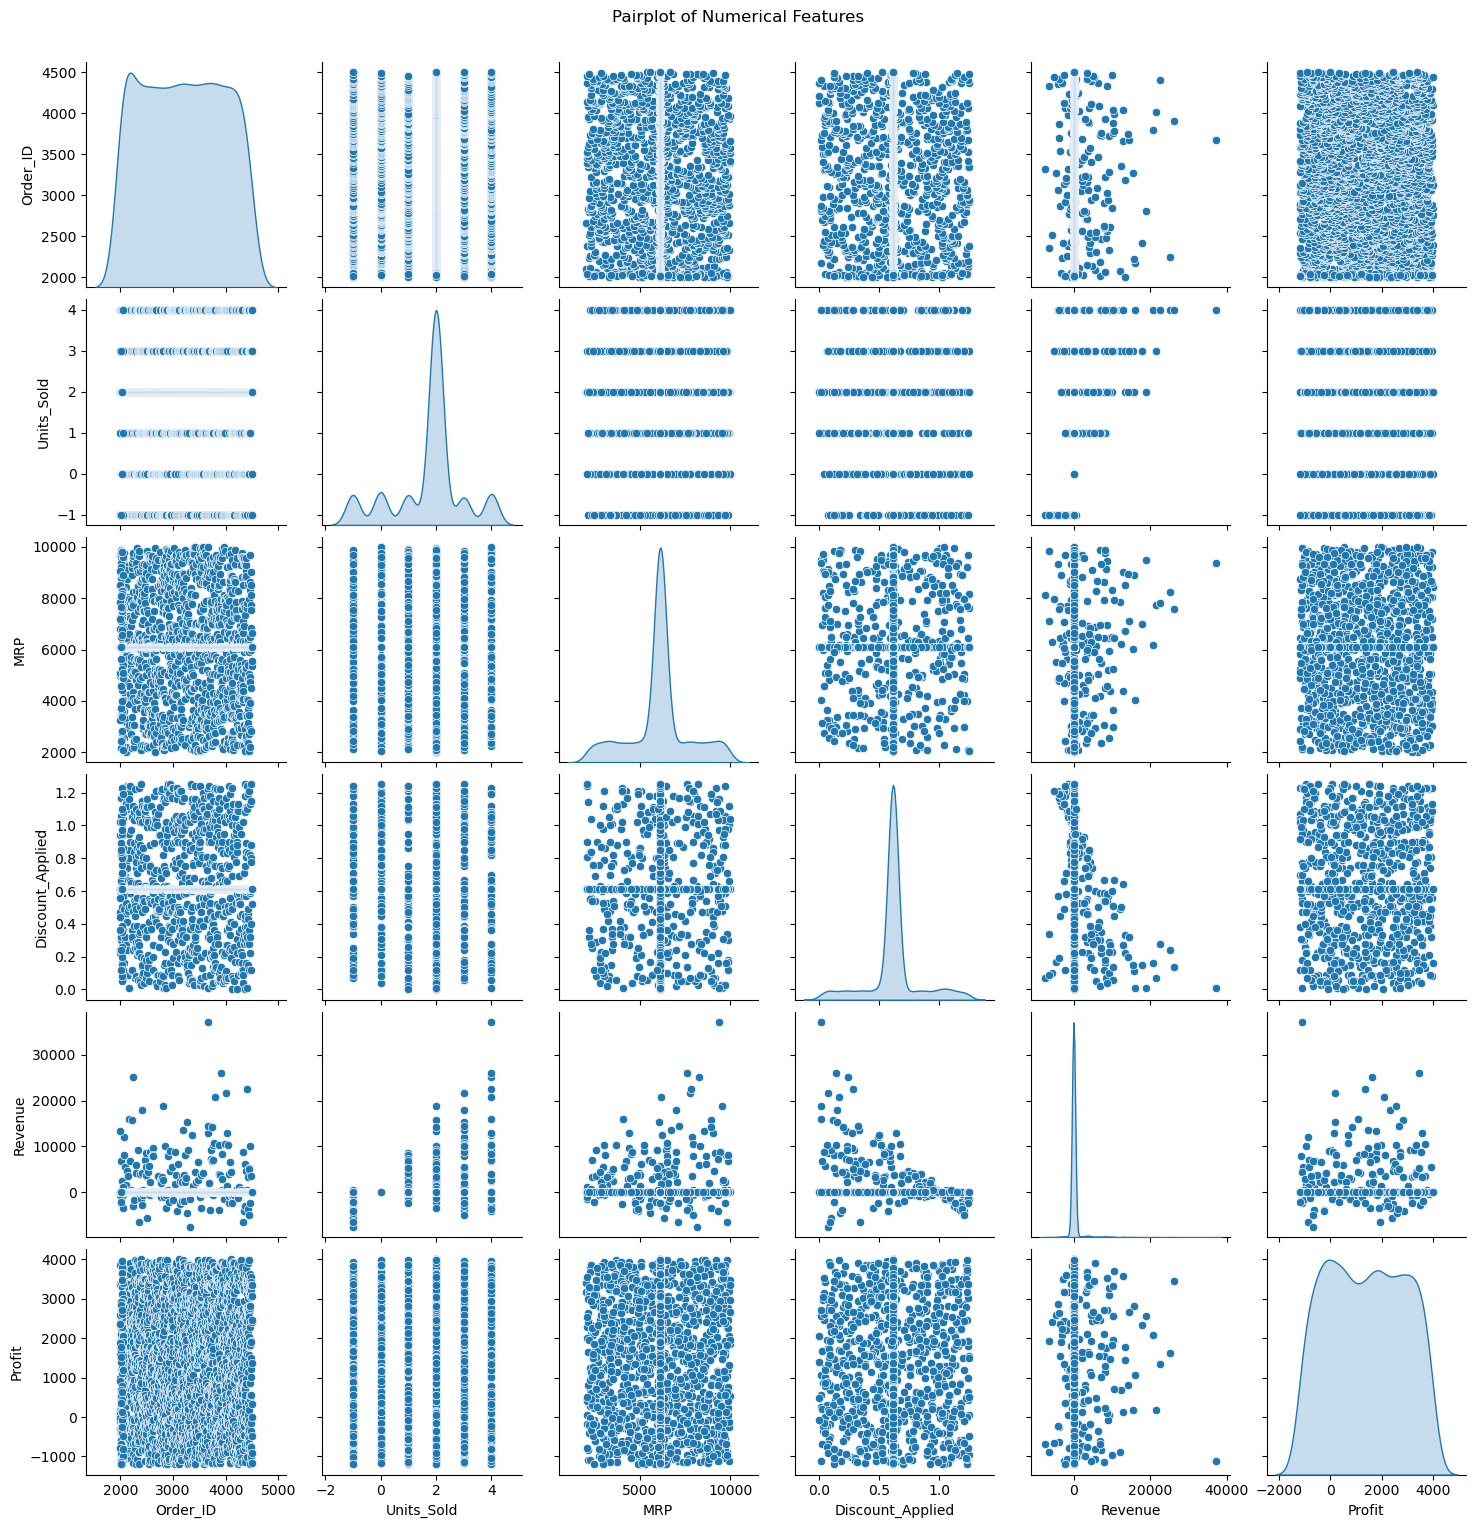

In [34]:
# create a pairplot to check data distribution
sns.pairplot(df, diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

Remove Outliers in profit, Revenue, Discount_Applied, MRP, Units_Sold 

Revenue and Units_Sold-Using IQR

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Gender_Category   2500 non-null   object 
 2   Product_Line      2500 non-null   object 
 3   Product_Name      2500 non-null   object 
 4   Units_Sold        2500 non-null   float64
 5   MRP               2500 non-null   float64
 6   Discount_Applied  2500 non-null   float64
 7   Revenue           2500 non-null   float64
 8   Sales_Channel     2500 non-null   object 
 9   Region            2500 non-null   object 
 10  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 215.0+ KB


In [36]:
# select columns you want to handle
for col in ['Revenue', 'Units_Sold']:
    
    # define q1 for each variable
    q1 = df[col].quantile(0.25)

In [37]:
 # define q3 for each variable
q3 = df[col].quantile(0.75)

In [38]:
# calculate iqr for each variable
iqr = q3 - q1

In [39]:
 # calculate the lower bound
lower_bound = q1 - 1.5 * iqr
lower_bound

np.float64(-0.5)

In [40]:
# calculate the upper bound
upper_bound = q3 + 1.5 * iqr
upper_bound

np.float64(3.5)

In [41]:
# remove outliers for each variable
df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2083 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2083 non-null   int64  
 1   Gender_Category   2083 non-null   object 
 2   Product_Line      2083 non-null   object 
 3   Product_Name      2083 non-null   object 
 4   Units_Sold        2083 non-null   float64
 5   MRP               2083 non-null   float64
 6   Discount_Applied  2083 non-null   float64
 7   Revenue           2083 non-null   float64
 8   Sales_Channel     2083 non-null   object 
 9   Region            2083 non-null   object 
 10  Profit            2083 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 195.3+ KB


Profit, Discount_Applied and MRP-Using Modified Z-Score


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2083 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2083 non-null   int64  
 1   Gender_Category   2083 non-null   object 
 2   Product_Line      2083 non-null   object 
 3   Product_Name      2083 non-null   object 
 4   Units_Sold        2083 non-null   float64
 5   MRP               2083 non-null   float64
 6   Discount_Applied  2083 non-null   float64
 7   Revenue           2083 non-null   float64
 8   Sales_Channel     2083 non-null   object 
 9   Region            2083 non-null   object 
 10  Profit            2083 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 195.3+ KB


In [44]:
# select only the numeric columns you want to handle
num_cols = ['Profit','MRP','Discount_Applied']

In [45]:
# Apply the Modified Z-Score method
for col in num_cols:
    median = df[col].median()
    mad = (abs(df[col] - median)).median()
    df[f'{col}_modified_z'] = 0.6745 * (df[col] - median) / mad
    df[f'{col}_is_outlier'] = abs(df[f'{col}_modified_z']) > 3.5

In [46]:
# Drop columns with names ending in '_modified_z' or '_is_outlier'
columns_to_drop = [col for col in df.columns if col.endswith('_modified_z') or col.endswith('_is_outlier')]
df = df.drop(columns=columns_to_drop)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2083 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2083 non-null   int64  
 1   Gender_Category   2083 non-null   object 
 2   Product_Line      2083 non-null   object 
 3   Product_Name      2083 non-null   object 
 4   Units_Sold        2083 non-null   float64
 5   MRP               2083 non-null   float64
 6   Discount_Applied  2083 non-null   float64
 7   Revenue           2083 non-null   float64
 8   Sales_Channel     2083 non-null   object 
 9   Region            2083 non-null   object 
 10  Profit            2083 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 195.3+ KB


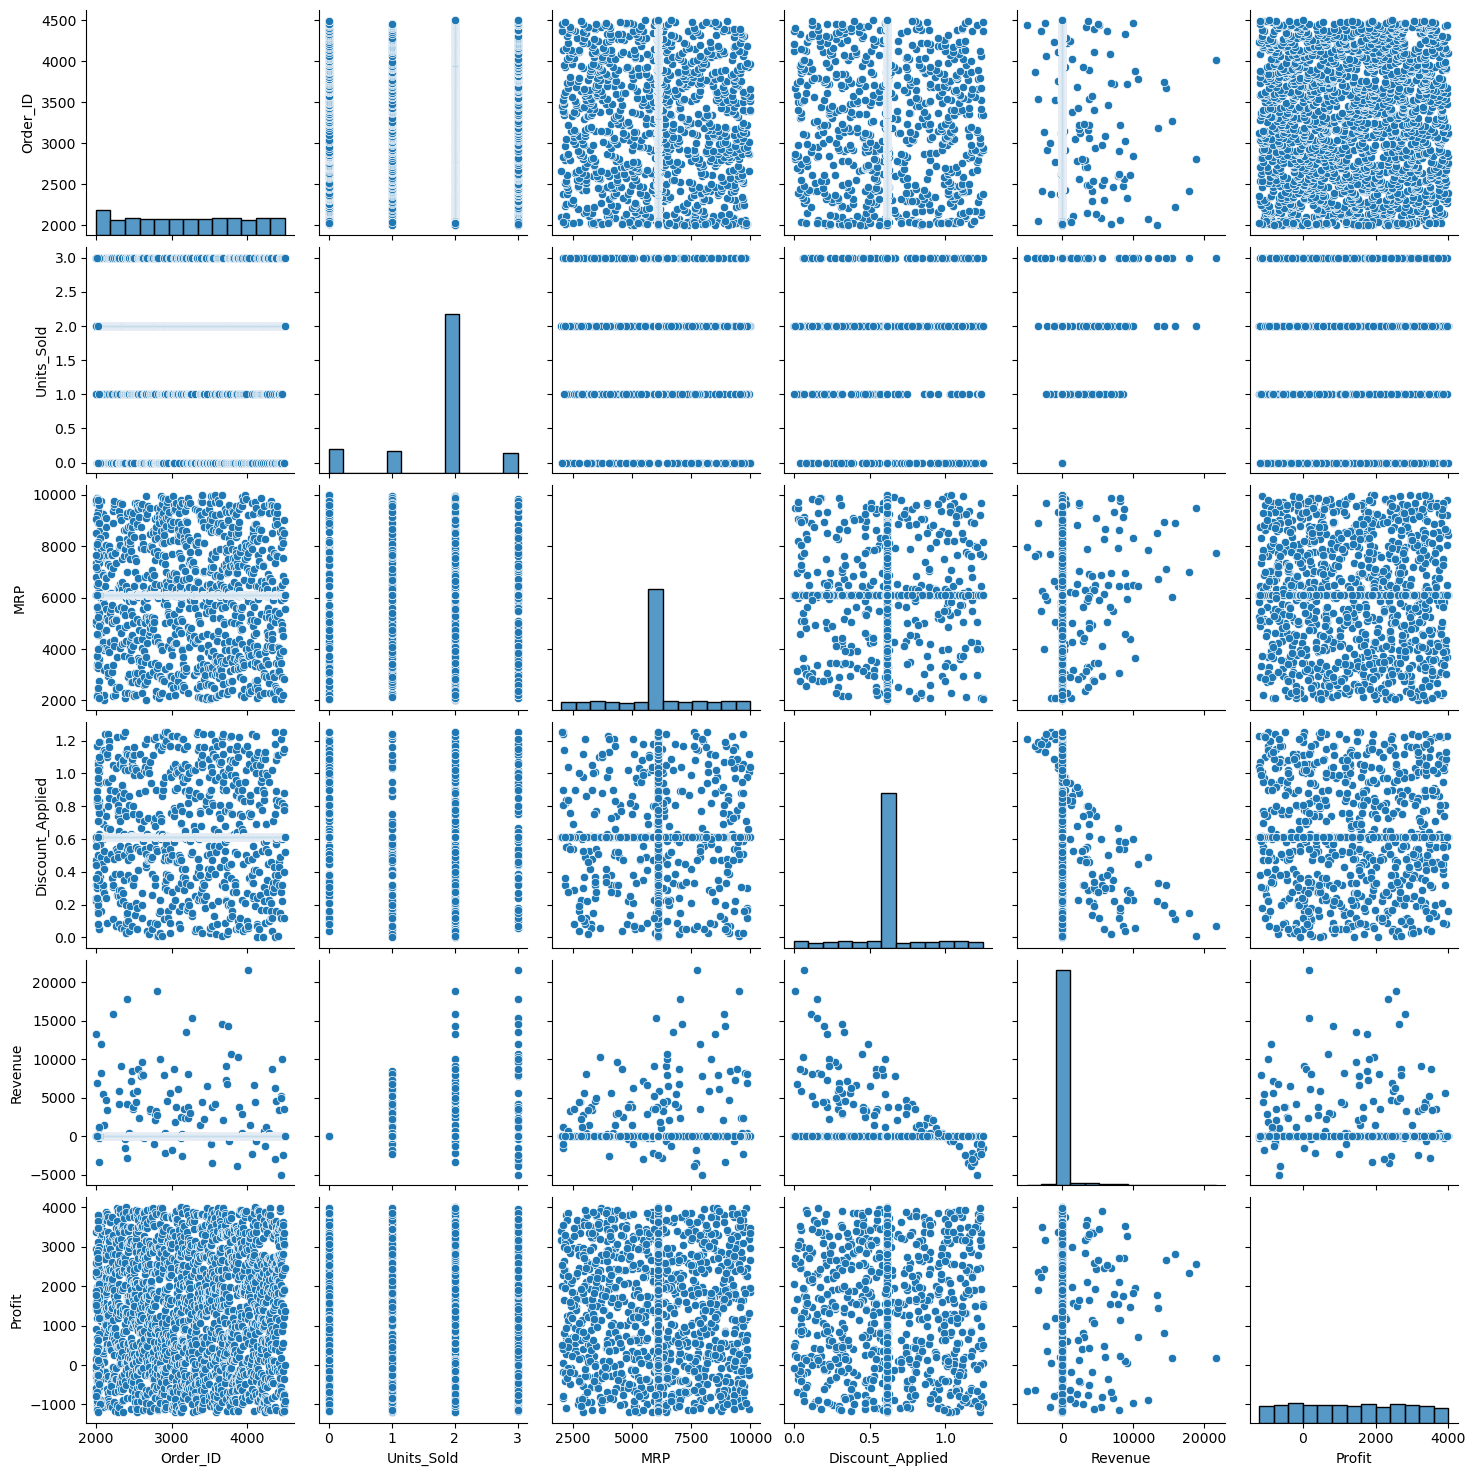

In [48]:
# print df.info()
# create a pairplot
sns.pairplot(df)

In [49]:
#Save the cleaned data
df.to_csv('FinalNikeSales_Cleaned.csv', index=False)

## Exploratory Data Analysis 

#### Numerical and Aggregated Variables


In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
#Load the cleaned data set 'NikeSales_Cleaned.csv'
df = pd.read_csv('FinalNikeSales_Cleaned.csv')

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2083 entries, 0 to 2082
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2083 non-null   int64  
 1   Gender_Category   2083 non-null   object 
 2   Product_Line      2083 non-null   object 
 3   Product_Name      2083 non-null   object 
 4   Units_Sold        2083 non-null   float64
 5   MRP               2083 non-null   float64
 6   Discount_Applied  2083 non-null   float64
 7   Revenue           2083 non-null   float64
 8   Sales_Channel     2083 non-null   object 
 9   Region            2083 non-null   object 
 10  Profit            2083 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 179.1+ KB


In [53]:
# show descriptive statistics 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order_ID,2083.0,3207.428709,746.677463,2000.00,2554.500,3201.000,3849.500,4499.00
Units_Sold,2083.0,1.777244,0.753679,0.00,2.000,2.000,2.000,3.00
MRP,2083.0,6080.541704,1644.409666,2006.63,6110.030,6110.030,6110.030,9995.55
Discount_Applied,2083.0,0.620454,0.212954,0.00,0.615,0.615,0.615,1.25
Revenue,2083.0,233.935300,1535.919467,-5010.39,0.000,0.000,0.000,21586.98
Profit,2083.0,1361.577115,1481.887204,-1199.32,67.005,1368.590,2636.440,3999.21


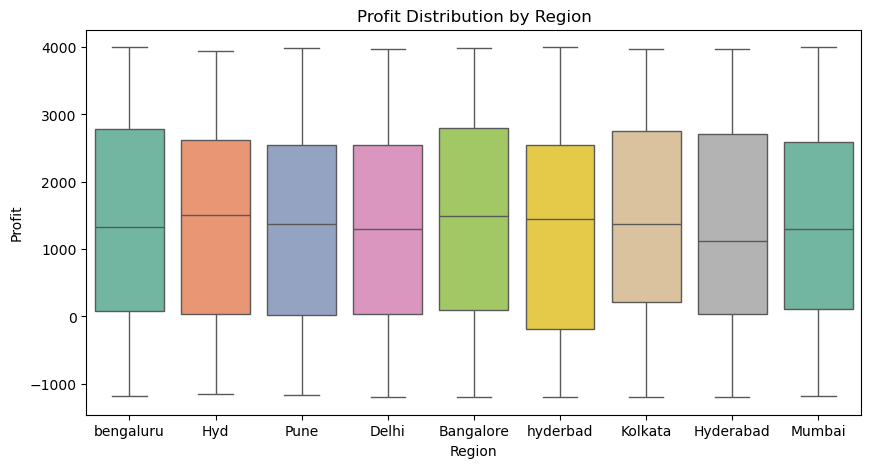

In [54]:
#Visualizing Distribution (Boxplots)
# 1. Profit distribution by Region
plt.figure(figsize=(10,5))
sns.boxplot(x='Region', y='Profit', data=df, palette='Set2')
plt.title('Profit Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.show()

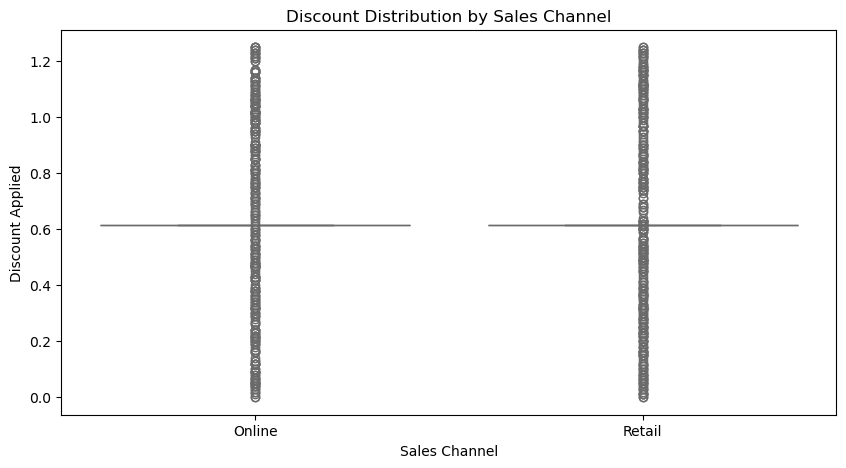

In [55]:
# 2. Discount distribution by Sales Channel
plt.figure(figsize=(10,5))
sns.boxplot(x='Sales_Channel', y='Discount_Applied', data=df, palette='Set3')
plt.title('Discount Distribution by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Discount Applied')
plt.show()

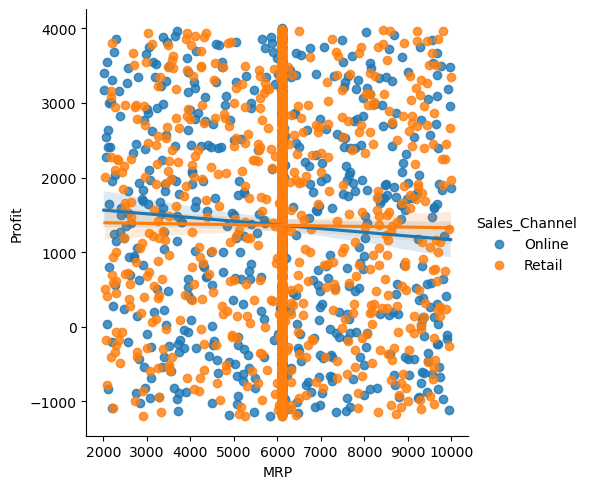

In [56]:
#Relationship Between MRP and Profit by Sales Channel
sns.lmplot(x='MRP', y='Profit', hue='Sales_Channel', data=df)

Aggregate by Region — Total & Average Profit, Product Line performance

In [57]:
# Which region has the highest and lowest average profit?
# Create a bar chart sorted from highest to lowest.
average_profit = df.groupby('Region')['Profit'].mean().sort_values(ascending=False)
average_profit

Region
Kolkata      1462.602948
Bangalore    1431.931484
Hyd          1428.408125
Mumbai       1348.035220
Pune         1339.798222
bengaluru    1339.124486
Hyderabad    1312.512991
hyderbad     1293.006585
Delhi        1291.876586
Name: Profit, dtype: float64

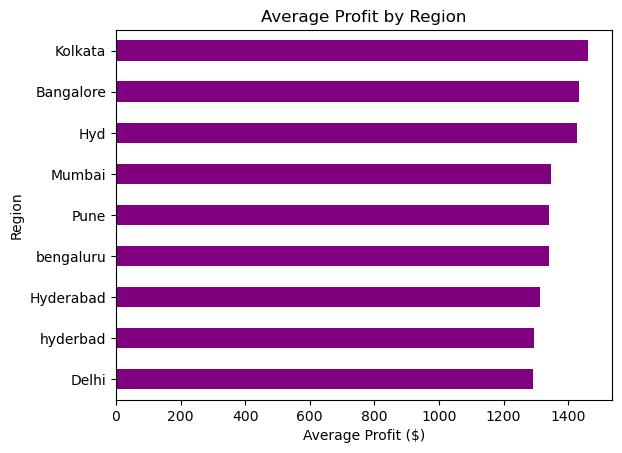

In [58]:
# Create a bar chart for Average Profit by Region
average_profit.sort_values().plot(kind='barh', color='Purple')

plt.title('Average Profit by Region')
plt.xlabel('Average Profit ($)')
plt.ylabel('Region')
plt.show()

Aggregate by Product Line — Average Profit & Revenue, Regional sales and profit comparison

In [59]:
# Which product line has the highest and lowest average profit & revenue?
# Create a table sorted from highest to lowest average profit.
average_profit_revenue = df.groupby('Product_Line')[['Profit']].mean().sort_values(by='Profit', ascending=False)
average_profit_revenue

,Profit
Product_Line,
Soccer,1392.081835
Running,1390.809220
Training,1373.909888
Basketball,1341.454391
Lifestyle,1310.711139


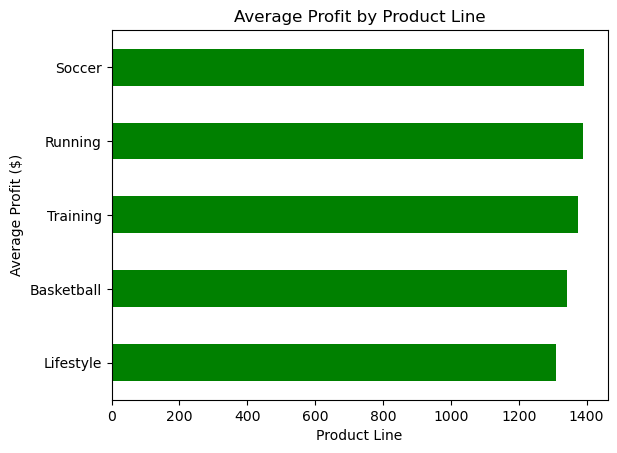

In [60]:
# Create a pie chart sorted from highest to lowest.
average_profit_revenue['Profit'].sort_values(ascending=True).plot(kind='barh', color='green')

plt.title('Average Profit by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Average Profit ($)')
plt.show()

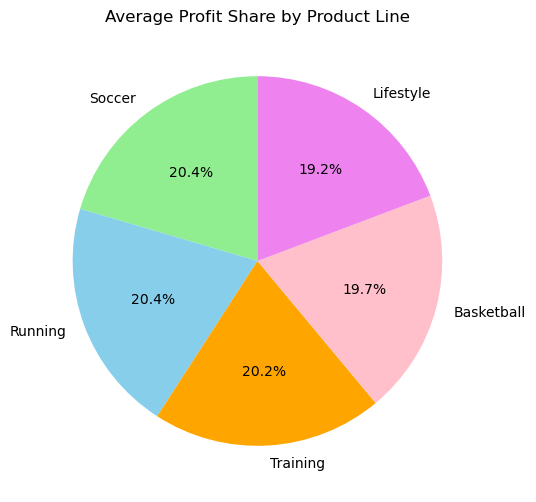

In [61]:
# Create a pie chart to show the proportion of average profit by product line.
average_profit_revenue['Profit'].plot(kind='pie',autopct='%1.1f%%',startangle=90,figsize=(6,6),colors=['lightgreen', 'skyblue', 'orange', 'pink', 'violet', 'gold'])
plt.title('Average Profit Share by Product Line')
plt.ylabel('') 
plt.show()

*The bar chart average profit by product line and bar chart is the same thing l was exploring my data*


Aggregate by Sales Channel — Comparing Online vs Retail, Sales Channel insights (Online vs Retail)

In [62]:
# Which sales channel performs better in terms of revenue and profit?
# Create a summary sorted from highest to lowest profit.
channel_summary = df.groupby('Sales_Channel')[['Revenue', 'Profit', 'Discount_Applied', 'Units_Sold']].agg({'Revenue': 'sum','Profit': 'sum','Discount_Applied': 'mean','Units_Sold': 'sum'}).sort_values(by='Profit', ascending=False)

channel_summary

,Revenue,Profit,Discount_Applied,Units_Sold
Sales_Channel,,,,
Retail,279656.09,1427259.31,0.617488,1868.0
Online,207631.14,1408905.82,0.623462,1834.0


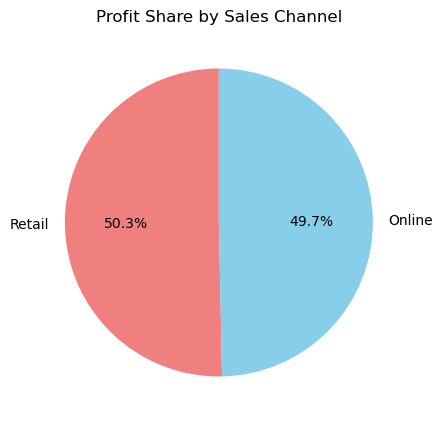

In [63]:
# Create a pie chart sorted from highest to lowest profitable channel 
channel_summary['Profit'].plot(kind='pie',autopct='%1.1f%%',startangle=90,colors=['lightcoral', 'skyblue'],figsize=(5,5))
plt.title('Profit Share by Sales Channel')
plt.ylabel('')
plt.show()

In [64]:
# Check the relationship between Discount, Revenue, and Profit
# Create a new aggregated dataset (optional)
agg_nike = df[['Discount_Applied', 'Revenue', 'Profit']]

# Correlation matrix
agg_nike.corr()


,Discount_Applied,Revenue,Profit
Discount_Applied,1.000000,-0.257324,0.002435
Revenue,-0.257324,1.000000,-0.001018
Profit,0.002435,-0.001018,1.000000


In [65]:
# Pearson correlation between Profit and Discount
from scipy import stats

stats.pearsonr(agg_nike['Profit'], agg_nike['Discount_Applied'])

PearsonRResult(statistic=np.float64(0.0024354016029774564), pvalue=np.float64(0.9115490085904336))

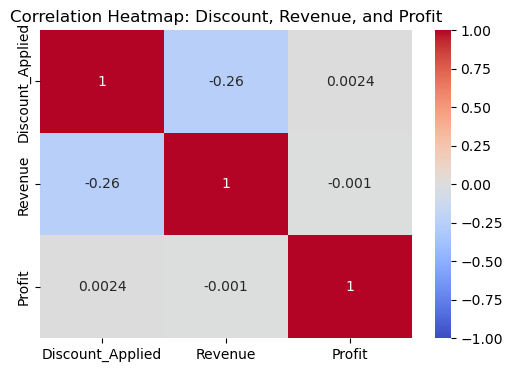

In [66]:
# Create a correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(agg_nike.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap: Discount, Revenue, and Profit')
plt.show()

In [67]:
# check missing?
df.isna().sum()

Order_ID            0
Gender_Category     0
Product_Line        0
Product_Name        0
Units_Sold          0
MRP                 0
Discount_Applied    0
Revenue             0
Sales_Channel       0
Region              0
Profit              0
dtype: int64

In [68]:
# check duplicates
df.duplicated().sum()

np.int64(0)

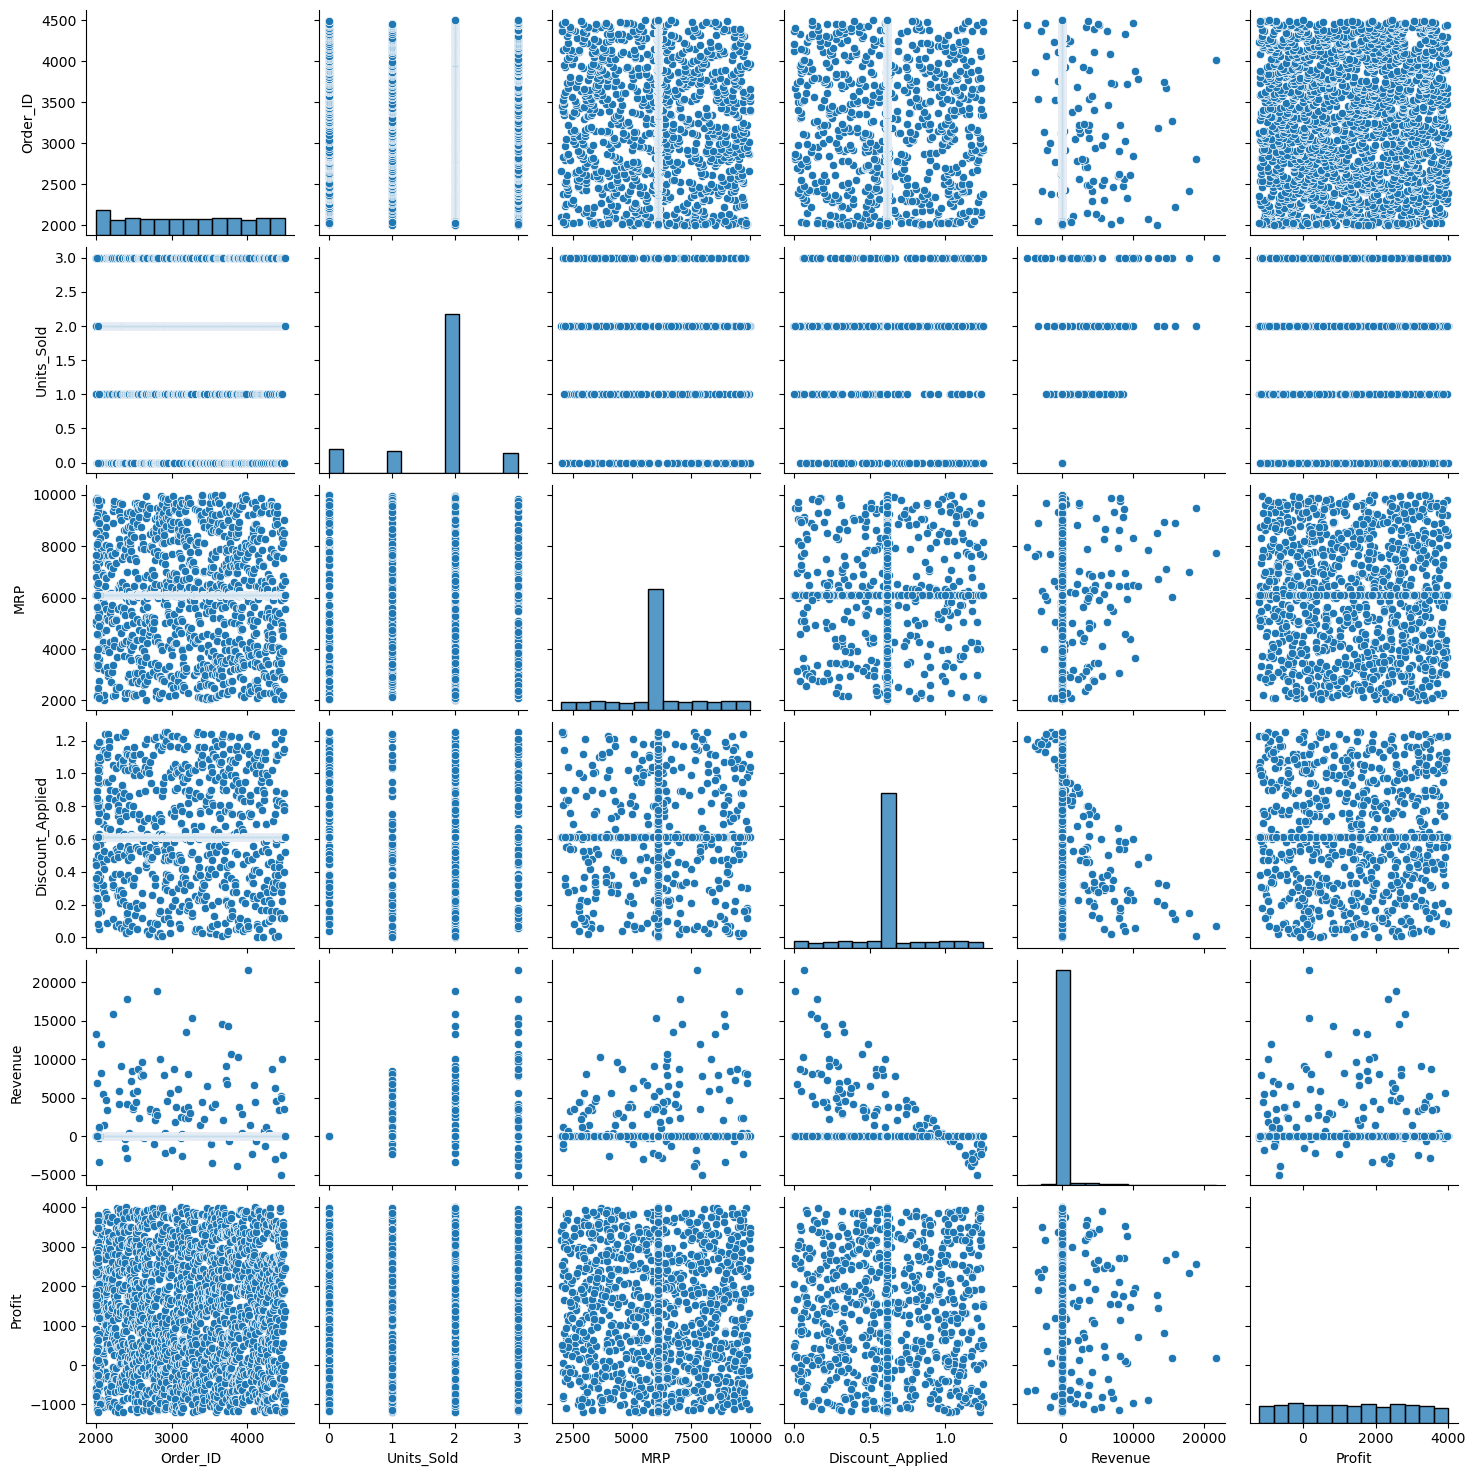

In [69]:
# create a pairplot 
sns.pairplot(df)

## One-hot encoding

In [70]:
# one-hot encoding
df=pd.get_dummies(data=df, columns=['Gender_Category', 'Product_Line', 'Product_Name', 'Sales_Channel', 'Region'], drop_first=True)

In [71]:
# check first five rows 
df.head()

,Order_ID,Units_Sold,MRP,Discount_Applied,Revenue,Profit,Gender_Category_Men,Gender_Category_Women,Product_Line_Lifestyle,Product_Line_Running,...,Product_Name_ZoomX Invincible,Sales_Channel_Retail,Region_Delhi,Region_Hyd,Region_Hyderabad,Region_Kolkata,Region_Mumbai,Region_Pune,Region_bengaluru,Region_hyderbad
0,2000,2.0,6110.03,0.470,0.0,-770.45,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,2001,3.0,4957.93,0.615,0.0,-112.53,False,True,False,False,...,False,True,False,True,False,False,False,False,False,False
2,2003,2.0,9673.57,0.615,0.0,3376.85,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,2004,2.0,6110.03,0.615,0.0,187.89,False,False,False,True,...,False,True,True,False,False,False,False,False,False,False
4,2005,1.0,7363.96,0.615,0.0,1415.98,False,True,False,False,...,False,True,True,False,False,False,False,False,False,False


## Define X and Y

In [72]:
# define y 
y = df['Profit']

In [73]:
# share y shape 
y.shape

(2083,)

In [74]:
# define X 
X = df.drop(columns='Profit')
X

,Order_ID,Units_Sold,MRP,Discount_Applied,Revenue,Gender_Category_Men,Gender_Category_Women,Product_Line_Lifestyle,Product_Line_Running,Product_Line_Soccer,...,Product_Name_ZoomX Invincible,Sales_Channel_Retail,Region_Delhi,Region_Hyd,Region_Hyderabad,Region_Kolkata,Region_Mumbai,Region_Pune,Region_bengaluru,Region_hyderbad
0,2000,2.0,6110.03,0.470,0.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,2001,3.0,4957.93,0.615,0.0,False,True,False,False,True,...,False,True,False,True,False,False,False,False,False,False
2,2003,2.0,9673.57,0.615,0.0,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,2004,2.0,6110.03,0.615,0.0,False,False,False,True,False,...,False,True,True,False,False,False,False,False,False,False
4,2005,1.0,7363.96,0.615,0.0,False,True,False,False,False,...,False,True,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2078,4492,2.0,6110.03,0.615,0.0,True,False,True,False,False,...,False,True,False,False,False,False,True,False,False,False
2079,4494,2.0,6110.03,0.615,0.0,False,True,False,False,False,...,True,False,False,False,False,True,False,False,False,False
2080,4495,3.0,6110.03,0.615,0.0,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2081,4497,2.0,6647.60,0.520,0.0,True,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False


In [75]:
# check X shape
X.shape

(2083, 39)

## Normalize Numerical Variables (Features)

In [76]:
# import moduels; from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler 


In [77]:
#Drop Order_ID from X
X = X.drop(columns=['Order_ID'])

In [78]:
# slicing variables for standard scaling
for_st_scaler=X[['Units_Sold', 'MRP', 'Discount_Applied','Revenue']]
for_st_scaler

,Units_Sold,MRP,Discount_Applied,Revenue
0,2.0,6110.03,0.470,0.0
1,3.0,4957.93,0.615,0.0
2,2.0,9673.57,0.615,0.0
3,2.0,6110.03,0.615,0.0
4,1.0,7363.96,0.615,0.0
...,...,...,...,...
2078,2.0,6110.03,0.615,0.0
2079,2.0,6110.03,0.615,0.0
2080,3.0,6110.03,0.615,0.0
2081,2.0,6647.60,0.520,0.0


In [79]:
#initialize standard scaler & fit and transform data, 'scaled'
scaled=StandardScaler().fit_transform(for_st_scaler)

In [80]:
# scaling numerical attributes, except for dummies
X[['Units_Sold', 'MRP', 'Discount_Applied', 'Revenue']]=pd.DataFrame(scaled, columns=for_st_scaler.columns)

In [81]:
# check frist/last rows
X

,Units_Sold,MRP,Discount_Applied,Revenue,Gender_Category_Men,Gender_Category_Women,Product_Line_Lifestyle,Product_Line_Running,Product_Line_Soccer,Product_Line_Training,...,Product_Name_ZoomX Invincible,Sales_Channel_Retail,Region_Delhi,Region_Hyd,Region_Hyderabad,Region_Kolkata,Region_Mumbai,Region_Pune,Region_bengaluru,Region_hyderbad
0,0.295629,0.017937,-0.706677,-0.152346,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
1,1.622773,-0.682848,-0.025616,-0.152346,False,True,False,False,True,False,...,False,True,False,True,False,False,False,False,False,False
2,0.295629,2.185521,-0.025616,-0.152346,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,0.295629,0.017937,-0.025616,-0.152346,False,False,False,True,False,False,...,False,True,True,False,False,False,False,False,False,False
4,-1.031515,0.780661,-0.025616,-0.152346,False,True,False,False,False,True,...,False,True,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2078,0.295629,0.017937,-0.025616,-0.152346,True,False,True,False,False,False,...,False,True,False,False,False,False,True,False,False,False
2079,0.295629,0.017937,-0.025616,-0.152346,False,True,False,False,False,True,...,True,False,False,False,False,True,False,False,False,False
2080,1.622773,0.017937,-0.025616,-0.152346,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2081,0.295629,0.344923,-0.471828,-0.152346,True,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False


## Train_Test_Split 

In [82]:
# import module; from sklearn.model_selection import train_test split
from sklearn.model_selection import train_test_split

In [83]:
# split train and test dataset, 80% train, 20% test dataset
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [84]:
# check the shape of X_train, X_test, y_train, y_test
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1666, 38)
(417, 38)
(1666,)
(417,)


## Model Pedictions


In [85]:
# import module; from sklearn.linear_model import LinearRegression
# import module; from sklearn.tree import DecisionTreeRegressor
# import module; from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression 
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

## 1 Decision Tree Regression 

In [86]:
# Initialize the models
dtr=DecisionTreeRegressor(random_state=42)

In [87]:
# Train the models
dtr.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [88]:
# Make predictions
pred_dtr = dtr.predict(X_test)

In [89]:
# chedk predictions 
pred_dtr

array([ 2.02747000e+03,  1.84655000e+03, -2.23300000e+02,  1.03080000e+02,
        1.69050000e+02,  2.96824000e+03,  1.91614000e+03, -2.37900000e+02,
        3.35131000e+03,  9.09760000e+02,  1.13538000e+03,  1.91674000e+03,
        2.83051000e+03,  3.70368000e+03, -1.10940000e+03,  2.23428000e+03,
        1.41129000e+03,  1.68050000e+03,  3.48564000e+03, -2.88770000e+02,
        1.04209000e+03, -1.03446000e+03, -4.48890000e+02,  7.69050000e+02,
        2.53062000e+03,  1.44002000e+03,  2.88229000e+03, -1.15815000e+03,
        3.35355000e+03,  3.03595000e+03, -1.12938000e+03,  1.50490000e+03,
        1.76536000e+03,  8.19420000e+02,  2.79791000e+03,  2.87586000e+03,
        2.51925000e+03,  8.64550000e+02, -8.16550000e+02,  2.23986000e+03,
       -2.44090000e+02,  2.44788000e+03, -7.44450000e+02, -4.00590000e+02,
        6.64300000e+01,  4.80160000e+02, -6.87950000e+02,  3.35476000e+03,
       -1.38780000e+02,  1.53846000e+03,  5.66340000e+02,  1.63150000e+02,
        1.19700000e+01,  

In [90]:
# from sklearn.metrics import mean_absolute_error and mean_squared_error  
from sklearn.metrics import mean_absolute_error,  mean_squared_error, r2_score

In [91]:
# calculate performance metrics for decision tree regressor, mae_dtr, mse_dtr, rmse_dtr
mae_dtr=mean_absolute_error(y_test, pred_dtr)
mse_dtr=mean_squared_error(y_test, pred_dtr)
rmse_dtr=np.sqrt(mse_dtr)
r2_dtr=r2_score(y_test, pred_dtr)

In [92]:
# create a dataframe -dtr_pm, making it integer 
dtr_pm=pd.DataFrame({'MAE':[mae_dtr], 'MSE':[mse_dtr], 'RMSE':[rmse_dtr], 'R2':[r2_dtr]}, index=['Decision Tree'])
dtr_pm

,MAE,MSE,RMSE,R2
Decision Tree,1759.301703,4.534652e+06,2129.472293,-0.978651


## 2 Decision Tree Regressor - Hyperparameter Tuned

In [93]:
# Estimator
# Initialize DecisionTreeClassifier 
dtr = DecisionTreeRegressor(random_state=42)

In [94]:
# Parameters
# For hyperparameter tuning # import GridSearchCV from sklearn.model_selection 
from sklearn.model_selection import GridSearchCV

In [95]:
# Grid of parameters to choose from
parameters ={'max_depth':[2,3,4,5,6,7,8,9, None], # max_depth=None tells the tree to grow as deep as it can until min_samples_leaf is hit.
             'min_samples_split':[2, 5,10,20], 'min_samples_leaf': [1, 5, 10, 20], 'max_features': [None, 'sqrt', 'log2']}

#### Cross-Validation

In [96]:
from sklearn.model_selection import KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42) 

#### GridSearch

In [97]:
# set the GridSearchCV with estimator, param_grid, scoring, cv=5
gridCV=GridSearchCV(dtr, parameters, scoring='neg_mean_absolute_error', cv=cv,  n_jobs=-1, verbose=1) 
# cv=cv(this is what we defined above, cv = KFold(n_splits=5, shuffle=True, random_state=42) )

In [98]:
# fit gridCV on train data
gridCV.fit(X_train, y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, None],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 5, 10, 20],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='neg_mean_absolute_error', verbose=1)

In [99]:
# Set the classifier to the best combination of parameters, gridCV.best_params_; 
gridCV.best_params_

{'max_depth': 2,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2}

In [100]:
# obtain the highest score achieved by the GridSearchCV.
gridCV.best_score_

np.float64(-1271.4811690223596)

In [101]:
# Set the classifier to the best combination of parameters(best_estimator_); 
gridCV.best_estimator_

DecisionTreeRegressor(max_depth=2, max_features='sqrt', random_state=42)

In [102]:
# Save it as dtr_tuned
dtr_tuned=gridCV.best_estimator_

In [103]:
# predict y (pred_dtrh) on X_test 
pred_dtrh = dtr_tuned.predict(X_test)

In [104]:
# import tree from sklearn 
from sklearn import tree

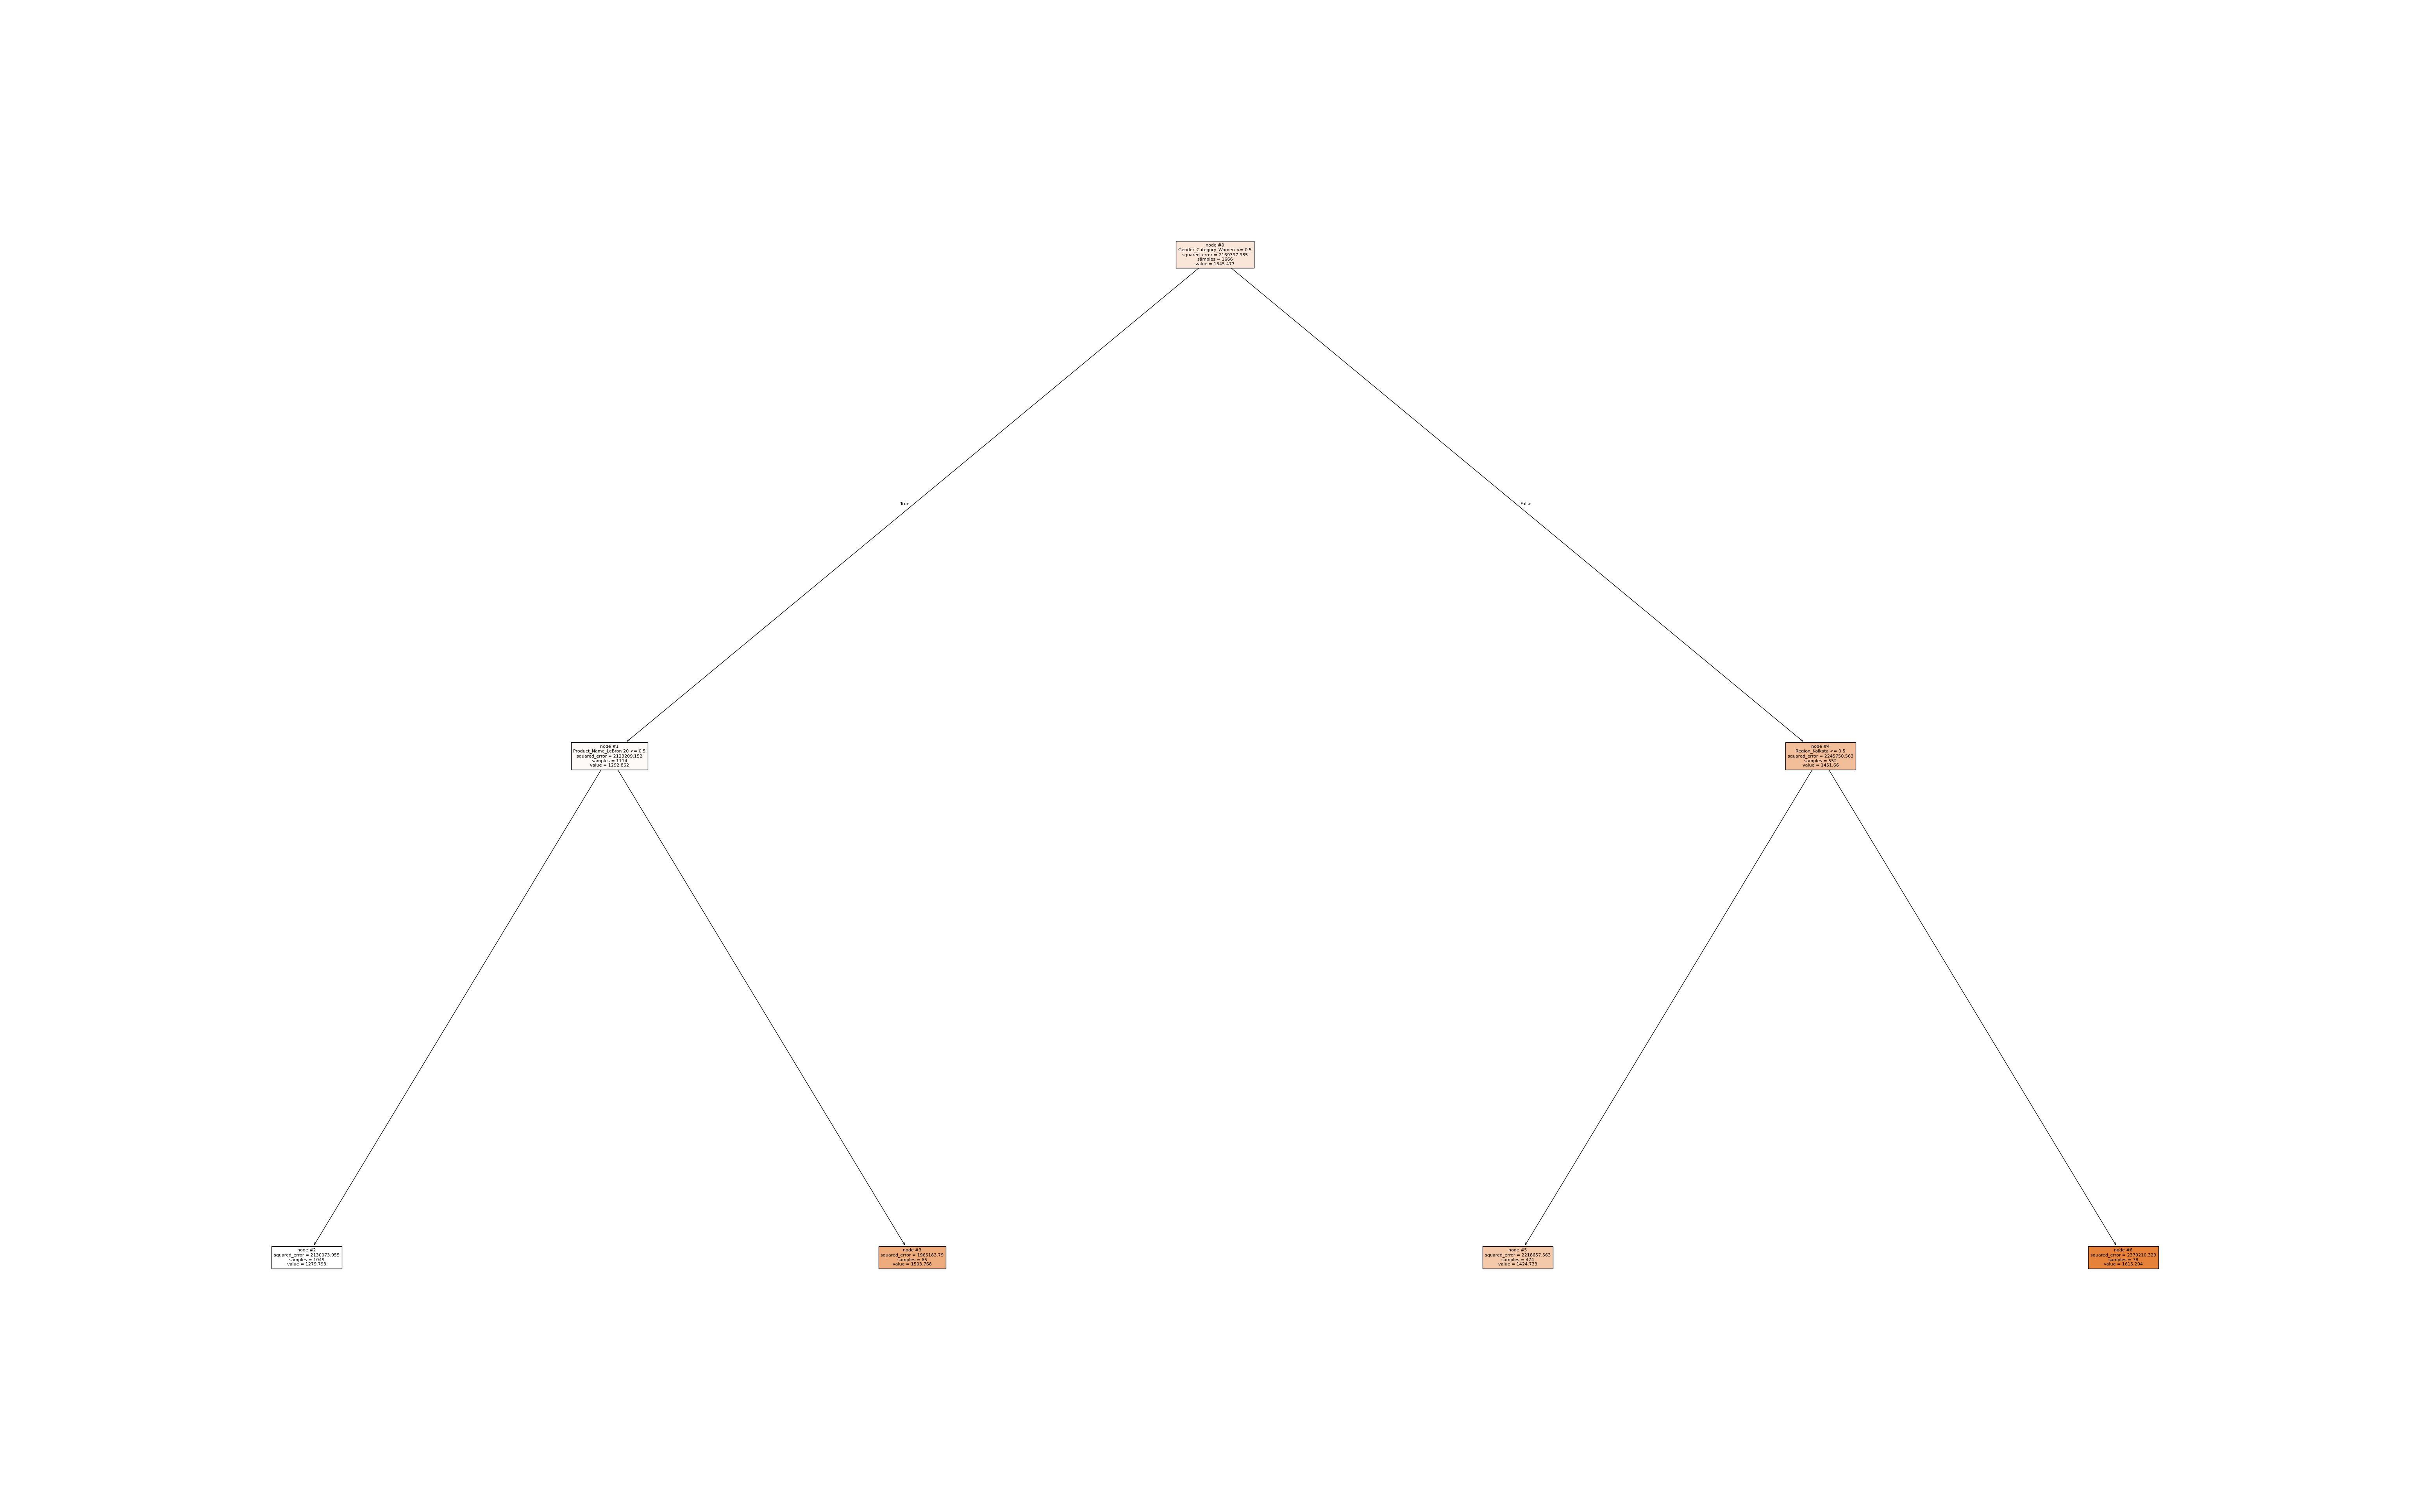

In [105]:
# plot the tree 
# set the size of the figure 
plt.figure(figsize=(80,50))
# tree.plot_tree() with model, feature_names, filled, node_ids, class_names, fontsize
tree.plot_tree(dtr_tuned, feature_names=X.columns, filled=True, node_ids=True, class_names=True, fontsize=8)
# show the plot 
plt.show()

In [106]:
# from sklearn.metrics import mean_absolute_error and mean_squared_error  
from sklearn.metrics import mean_absolute_error,  mean_squared_error, r2_score

In [107]:
# calculate performance metrics for decision tree regressor, mae_dtr, mse_dtr, rmse_dtr
mae_dtrh=mean_absolute_error(y_test, pred_dtrh)
mse_dtrh=mean_squared_error(y_test, pred_dtrh)
rmse_dtrh=np.sqrt(mse_dtrh)
r2_dtrh=r2_score(y_test, pred_dtrh)

In [108]:
# create a dataframe -dtr_pm, making it integer 
dtrh_pm=pd.DataFrame({'MAE':[mae_dtrh], 'MSE':[mse_dtrh], 'RMSE':[rmse_dtrh], 'R2':[r2_dtrh]}, index=['Decision Tree Regression Hyperparameter Tuned'])
dtrh_pm

,MAE,MSE,RMSE,R2
Decision Tree Regression Hyperparameter Tuned,1344.064099,2.316526e+06,1522.013922,-0.010794


## 3 Linear Regression

In [109]:
# import Linear Regression
from sklearn.linear_model import LinearRegression

In [110]:
# Initialize the model
lr_model = LinearRegression()

In [111]:
# Fit the model to the training data
lr_model.fit(X_train, y_train)

LinearRegression()

In [112]:
# Make predictions on the test data
pred_lr = lr_model.predict(X_test)

In [113]:
# check predictions 
pred_lr

array([1077.52014434, 1307.82084695, 1486.09775361, 1091.62717198,
       1422.15638364, 1420.09626008, 1498.55249598, 1468.28372549,
       1171.95052635, 1266.91460032, 1277.06621418, 1316.38034981,
       1647.95347911, 1325.50669509, 1302.95561826, 1617.23545223,
       1428.20424282, 1204.24873987, 1260.33994045, 1609.3041957 ,
       1406.48409864, 1037.60235437, 1278.27931841, 1433.23569661,
       1289.89453676, 1308.20839604, 1399.85582989, 1373.57898712,
       1454.75689463, 1205.12133064, 1146.80620266, 1387.6982647 ,
       1863.8650343 , 1372.82546311, 1202.46926095, 1531.54004599,
       1112.27007249, 1095.34946635, 1524.22659534, 1513.75267241,
       1367.07607068, 1139.4999868 , 1491.20507085, 1072.4130339 ,
       1617.57531407, 1214.71932596, 1536.2933052 , 1588.59342578,
       1470.56216955, 1188.77763542, 1416.37935992, 1231.72668946,
       1289.07008112, 1512.04279034, 1397.13777179, 1469.04568748,
       1399.41835982, 1036.33563057, 1147.79312397, 1267.74921

In [114]:
# calculate performance metrics for decision tree regressor, mae_dtr, mse_dtr, rmse_dtr
pred_lr = lr_model.predict(X_test)
mae_lr = mean_absolute_error(y_test, pred_lr)
mse_lr = mean_squared_error(y_test, pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, pred_lr)

In [115]:
# create a dataframe -dtr_pm, making it integer 
lr_pm=pd.DataFrame({'MAE':[mae_lr], 'MSE':[mse_lr], 'RMSE':[rmse_lr], 'R2':[r2_lr]}, index=['Linear Regression'])
lr_pm

,MAE,MSE,RMSE,R2
Linear Regression,1356.504426,2.394001e+06,1547.255814,-0.044599


## 4 K-Neighbors Regression

In [116]:
# import KNeighborsRegressor
from sklearn.neighbors import KNeighborsRegressor

In [117]:
# Initialize the model
knn_model = KNeighborsRegressor()

In [118]:
knn_model = KNeighborsRegressor(n_neighbors=5)

In [119]:
# Train the model
knn_model.fit(X_train, y_train)

KNeighborsRegressor()

In [120]:
KNeighborsRegressor(n_jobs=1)

KNeighborsRegressor(n_jobs=1)

In [121]:
# Make predictions
pred_knn = knn_model.predict(X_test)

In [122]:
# chedk predictions 
pred_knn

array([ 687.972,  433.926, 1514.962, 2003.712, 1005.842,  968.204,
        990.516, 1705.848,  195.158,  707.518,  551.154, 1341.19 ,
        913.024, 2956.968,  877.63 , 2614.542,  158.272, 1482.382,
       1293.45 , 1460.606, 1053.996,  915.24 ,  720.762, 1439.796,
       1236.294, 1064.008, 1130.464,  951.978, 1589.236,  800.964,
        152.988, 2139.35 , 1560.154, 1806.592,   21.282, 2458.066,
       1367.03 ,  219.036, 1987.568,  714.278, 1162.118, 2090.546,
       2269.466,  972.548, 1200.934, 1645.674, 1413.752, 1822.034,
       1304.69 , 1556.758, 1543.698,  164.63 , 1388.354, 1174.126,
       2223.924, 1052.25 , 1556.796, 2159.368,  857.696, 1137.666,
       1331.316, 1533.378, 2173.192, 1029.694, 2206.046, 2135.868,
        874.722,  767.484,  610.816, 1563.708, 1049.136, 2748.402,
        725.236, 1054.206, 2497.006, 2389.042, 1469.096, 1728.066,
        272.13 , -258.538, 1655.262,  700.722, 1841.468, 1025.236,
        297.242,  902.92 , 1358.11 , 1369.14 , 1893.468,  731.

In [123]:
# import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [124]:
# calculate performance metrics for linear regression
pred_knn = knn_model.predict(X_test)
mae_knn = mean_absolute_error(y_test, pred_knn)
mse_knn = mean_squared_error(y_test, pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, pred_knn)


In [125]:
print(mae_knn)
print(mse_knn)
print(rmse_knn)
print(r2_knn)

1402.9644844124698
2672419.6940896786
1634.7537105294114
-0.16608425836217378


In [126]:
# create a dataframe -lr_pm, making it integer 
knn_pm=pd.DataFrame({'MAE':[mae_knn], 'MSE':[mse_knn], 'RMSE':[rmse_knn], 'R2':[r2_lr]}, index=['K-Neighbors Regression']).astype(int)
knn_pm

,MAE,MSE,RMSE,R2
K-Neighbors Regression,1402,2672419,1634,0


# Advanced Regression models 

## 5. Random Forest Regressor - Hyperparameter Tuned

In [127]:
# import module; from sklearn.ensemble import RandomForestRegressor
# For hyperparameter tuning # import GridSearchCV and KFold from sklearn.model_selection 
# from sklearn.metrics import mean_absolute_error and mean_squared_error, r2_score 
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [128]:
#  Define the parameter grid 
parameters_rf ={'n_estimators': [100, 200], 'max_depth':[2,3,4,5,6,7,8,9],
             'min_samples_split':[2, 5,10,15, 20], 'min_samples_leaf': [1, 2, 5, 7, 9], 'max_features': [None, 'sqrt', 'log2']}

In [129]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)

In [130]:
# Instantiate GridSearchCV
# We set scoring to a regression metric 
cv = KFold(n_splits=5, shuffle=True, random_state=42)
# set the GridSearchCV with estimator, param_grid, scoring, cv=5
gridCV_rf=GridSearchCV(rf, parameters_rf, scoring='neg_mean_absolute_error', cv=cv,  n_jobs=-1, verbose=1)

In [131]:
# Fit the search
gridCV_rf.fit(X_train, y_train)

Fitting 5 folds for each of 1200 candidates, totalling 6000 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [2, 3, 4, 5, 6, 7, 8, 9],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 5, 7, 9],
                         'min_samples_split': [2, 5, 10, 15, 20],
                         'n_estimators': [100, 200]},
             scoring='neg_mean_absolute_error', verbose=1)

In [132]:
# Print the best results - best parameters found by GridSearch
gridCV_rf.best_estimator_

RandomForestRegressor(max_depth=2, max_features='log2', min_samples_leaf=7,
                      n_estimators=200, random_state=42)

In [133]:
# assign the model name, rf_tuned
rf_tuned=gridCV_rf.best_estimator_

In [134]:
# predict y using X_test 
pred_rfh=rf_tuned.predict(X_test)

In [135]:
# calculate performance metrics for random forest regressor hyperparameter tuned, mae_rfh, mse_rfh, rmse_rfh, r2_rfh
mae_rfh=mean_absolute_error(y_test, pred_rfh)
mse_rfh=mean_squared_error(y_test, pred_rfh)
rmse_rfh=np.sqrt(mean_squared_error(y_test, pred_rfh))
r2_rfh=r2_score(y_test, pred_rfh)

In [136]:
# create a dataframe -pm_rfh
pm_rfh=pd.DataFrame({'MAE':[mae_rfh], 'MSE':[mse_rfh], 'RMSE':[rmse_rfh], 'R2':[r2_rfh]}, index=['RandomForest Regressor Hyperparameter Tuned']).round(2)
pm_rfh

,MAE,MSE,RMSE,R2
RandomForest Regressor Hyperparameter Tuned,1340.12,2309161.35,1519.59,-0.01


## Final Model Comparison Summary

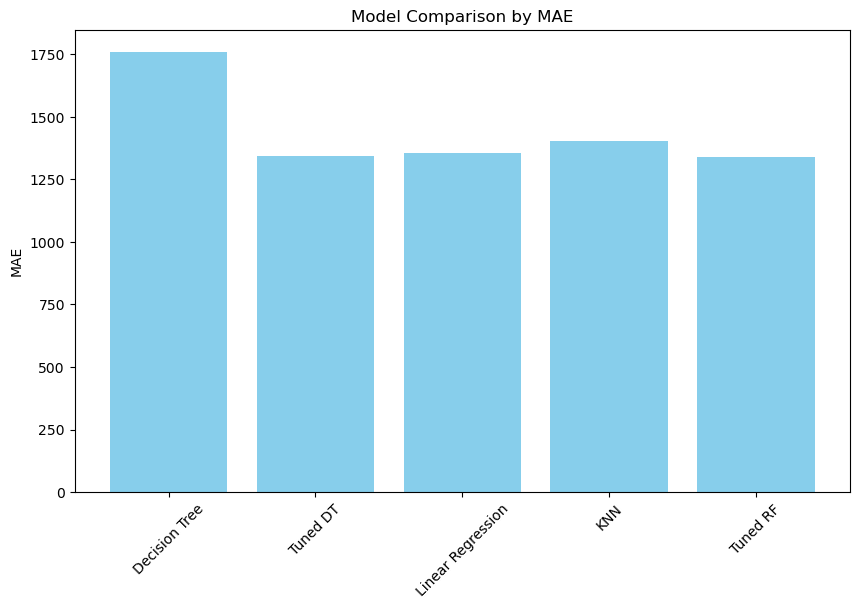

In [137]:
# Compare model performance using MAE across all five regression models 
# (Decision Tree, Tuned DT, Linear Regression, KNN, and Tuned Random Forest).
# This visualization helps identify which model has the lowest prediction error.
mae_values = [mae_dtr, mae_dtrh, mae_lr, mae_knn, mae_rfh]
models = ['Decision Tree', 'Tuned DT', 'Linear Regression', 'KNN', 'Tuned RF']

plt.figure(figsize=(10,6))
plt.bar(models, mae_values, color='skyblue')
plt.ylabel("MAE")
plt.title("Model Comparison by MAE")
plt.xticks(rotation=45)
plt.show()

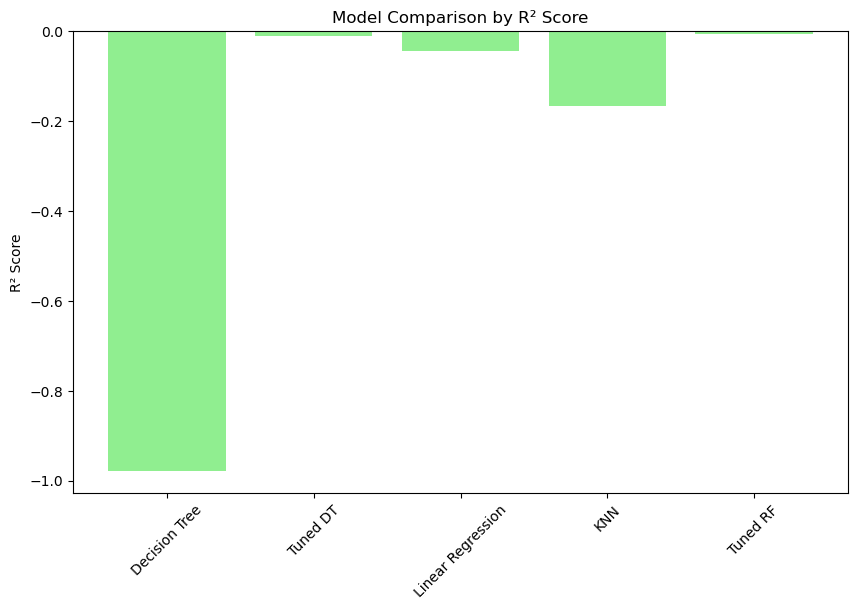

In [138]:
# Compare model performance using r2 across all five regression models 
# (Decision Tree, Tuned DT, Linear Regression, KNN, and Tuned Random Forest).
# This visualization helps identify which model has the lowest prediction error.
r2_values = [r2_dtr, r2_dtrh, r2_lr, r2_knn, r2_rfh]
models = ['Decision Tree', 'Tuned DT', 'Linear Regression', 'KNN', 'Tuned RF']

plt.figure(figsize=(10,6))
plt.bar(models, r2_values, color='lightgreen')
plt.ylabel("R² Score")
plt.title("Model Comparison by R² Score")
plt.xticks(rotation=45)
plt.show()

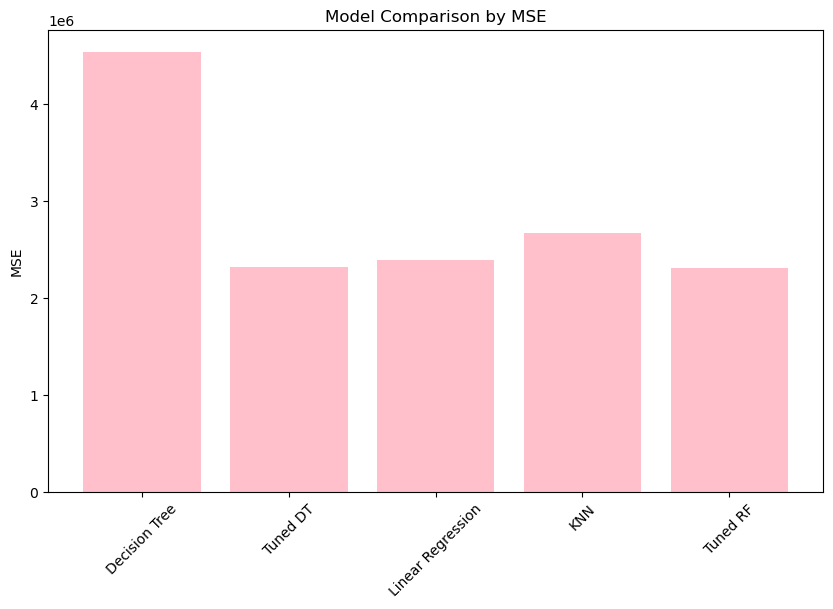

In [139]:
# Compare model performance using MSE across all five regression models 
# (Decision Tree, Tuned DT, Linear Regression, KNN, and Tuned Random Forest).
# This visualization helps identify which model has the lowest prediction error.
mse_values = [mse_dtr, mse_dtrh, mse_lr, mse_knn, mse_rfh]
models = ['Decision Tree', 'Tuned DT', 'Linear Regression', 'KNN', 'Tuned RF']

plt.figure(figsize=(10,6))
plt.bar(models, mse_values, color='pink')
plt.ylabel("MSE")
plt.title("Model Comparison by MSE")
plt.xticks(rotation=45)
plt.show()

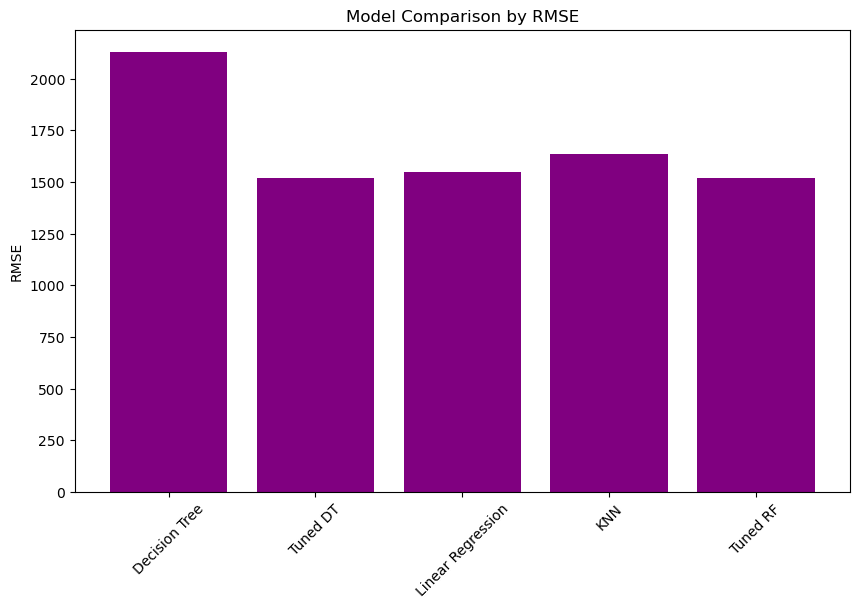

In [140]:
# Compare model performance using RMSE across all regression models.
# RMSE shows the average prediction error in the same units as the target variable (Profit),
# making it useful for understanding how far off predictions are in real business terms.

rmse_values = [rmse_dtr, rmse_dtrh, rmse_lr, rmse_knn, rmse_rfh]
models = ['Decision Tree', 'Tuned DT', 'Linear Regression', 'KNN', 'Tuned RF']

plt.figure(figsize=(10,6))
plt.bar(models, rmse_values, color='purple')
plt.ylabel("RMSE")
plt.title("Model Comparison by RMSE")
plt.xticks(rotation=45)
plt.show()

#### Feature Importances 

In [141]:
# Feature Importance (Random Forest)
importances = pd.Series(rf_tuned.feature_importances_, index=X.columns)

# Sort and show the top 10 most important features
importances = importances.sort_values(ascending=False).head(10)
importances

MRP                            0.139191
Discount_Applied               0.130858
Units_Sold                     0.071917
Gender_Category_Women          0.058995
Revenue                        0.056788
Region_Delhi                   0.043402
Region_Kolkata                 0.036236
Product_Name_React Infinity    0.030979
Product_Name_Zoom Freak        0.029202
Region_Pune                    0.028300
dtype: float64

<Axes: >

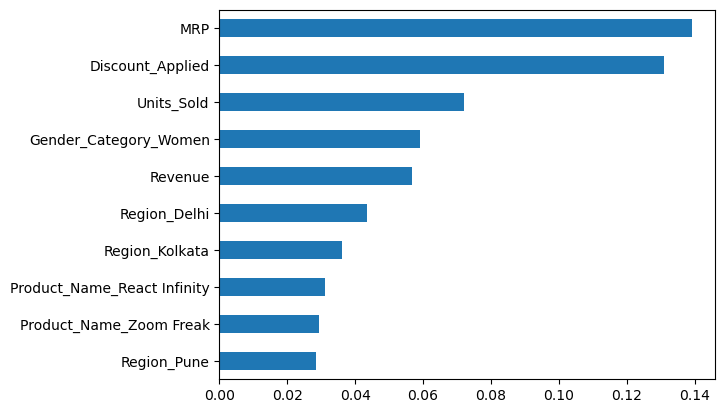

In [142]:
# create a bar chart 
importances.sort_values().plot(kind='barh')